# Chapter 5 Solutions: Quantum Annealing

---


---


In [1]:
# Solutions Setup (D-Wave)
import numpy as np
import matplotlib.pyplot as plt
import neal
from pyqubo import Binary, Array
import networkx as nx
from pyqubo import Binary, Array,Placeholder
from dimod.reference.samplers import ExactSolver
import neal
import openjij as oj
from dwave.system import LeapHybridSampler, DWaveSampler, EmbeddingComposite
import numpy as np
import matplotlib.pyplot as plt

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from Chapter05_QuantumAnnealing_functions import QATrussOptimizer, print_QUBO_best_result
print('Solutions setup complete!')

Solutions setup complete!


## Max cut graph problem

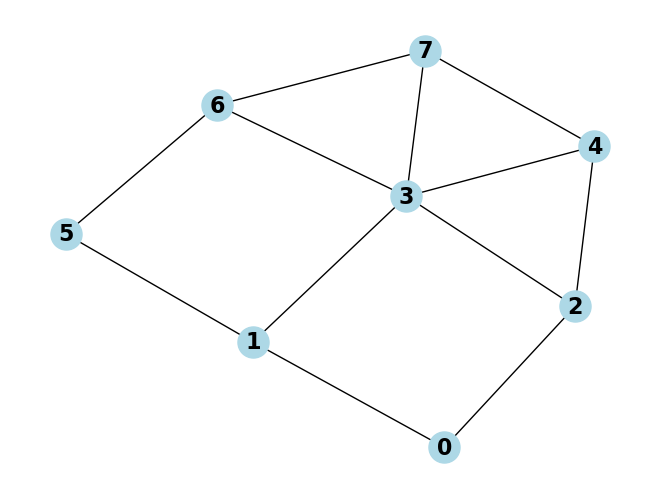

Exact:  q values: [0, 1, 1, 0, 1, 0, 1, 0]
Exact:  Lowest Energy: -10
SA:  q values: [1, 0, 0, 1, 0, 1, 0, 1]
SA:  Lowest Energy: -10
SQA:  q values: [1, 0, 0, 1, 1, 1, 0, 0]
SQA:  Lowest Energy: -10


([1, 0, 0, 1, 1, 1, 0, 0], np.float64(-10.0))

In [6]:
exact_sampler = ExactSolver() 
sa_sampler = neal.SimulatedAnnealingSampler()
sqa_sampler = oj.SQASampler()

G = nx.Graph() # convenient
G.add_edges_from([(0,1),(0,2),(1,3),(1,5),(2,3),(2,4),(3,4),(3,6),(3,7),(4,7),(5,6),(6,7)])

nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=16, font_weight='bold')
plt.show()
H = 0
q = Array.create("q",shape = 8,vartype = "BINARY")
for i, j in G.edges:# create H from graph
    H = H + 2*q[i]*q[j] - q[i] - q[j] # offset by 1

model = H.compile()
bqm = model.to_bqm()
 
exact_results = exact_sampler.sample(bqm)

print_QUBO_best_result(exact_results, method_name="Exact: ")

sa_results = sa_sampler.sample(bqm, num_reads=100)
print_QUBO_best_result(sa_results, method_name="SA: ")

sqa_results = sqa_sampler.sample(bqm, num_reads=100)
print_QUBO_best_result(sqa_results, method_name="SQA: ")

## Number partioning

In [7]:
# Given set
A = [25, 7, 13, 31, 42, 17, 21, 10]
S = sum(A)

# 1. Define Binary Variables
x = [Binary(f'x_{i}') for i in range(len(A))]

# 2. Define Hamiltonian: (2*sum(a_i * x_i) - S)^2
H = (2 * sum(A[i] * x[i] for i in range(len(A))) - S)**2

# 3. Compile and convert to BQM
model = H.compile()
bqm = model.to_bqm()

# 4. Solve using Simulated Annealing (as requested)
sampler = neal.SimulatedAnnealingSampler()
results = sampler.sample(bqm, num_reads=10)

# 5. Extract and print results
best_sample = results.first.sample
set1 = [A[i] for i in range(len(A)) if best_sample[f'x_{i}'] == 1]
set2 = [A[i] for i in range(len(A)) if best_sample[f'x_{i}'] == 0]

print(f"Set 1: {set1} (Sum: {sum(set1)})")
print(f"Set 2: {set2} (Sum: {sum(set2)})")
print(f"Difference: {abs(sum(set1) - sum(set2))}")

Set 1: [25, 7, 13, 17, 21] (Sum: 83)
Set 2: [31, 42, 10] (Sum: 83)
Difference: 0


## 2.2 Solving QUBO Problems using D-Wave
### Factoring the bi-prime 143
p = 1 p2 p1 1  <br>
q = 1 q2 q1 1 <br>
Exact solution  <br>
p = 1 0 1 1 = 11 <br>
q = 1 1 0 1 = 13 <br>
Reference: Quantum factorization of 56153 with only 4 qubits, Dattani 2014 <br>

In [2]:
p1,p2,q1,q2 = Binary("p1"), Binary("p2"),Binary("q1"), Binary("q2")  # type: ignore
H  = (p1+q1-1)**2 +  (p2+q2-1)**2 +  (p2*q1+p1*q2-1)**2 
model = H.compile()
bqm = model.to_bqm()

sampler = ExactSolver()   # type: ignore
results = sampler.sample(bqm)
print(results)

sampler = neal.SimulatedAnnealingSampler()  # type: ignore
results = sampler.sample(bqm)
print(results)

   p1 p1 * q2 p2 p2 * q1 q1 q2 energy num_oc.
13  1       1  0       0  0  1    0.0       1
39  0       0  1       1  1  0    0.0       1
18  1       1  1       0  0  1    1.0       1
30  1       0  1       0  0  0    1.0       1
36  0       0  1       1  1  1    1.0       1
38  1       0  1       1  1  0    1.0       1
50  1       1  0       0  1  1    1.0       1
60  0       0  0       0  1  1    1.0       1
1   1       0  0       0  0  0    2.0       1
3   0       0  0       0  0  1    2.0       1
31  0       0  1       0  0  0    2.0       1
63  0       0  0       0  1  0    2.0       1
0   0       0  0       0  0  0    3.0       1
28  0       0  1       0  0  1    3.0       1
42  1       1  1       1  1  1    3.0       1
62  1       0  0       0  1  0    3.0       1
17  1       1  1       0  0  0    5.0       1
25  1       0  1       1  0  0    5.0       1
51  0       1  0       0  1  1    5.0       1
59  0       0  0       1  1  1    5.0       1
2   1       0  0       0  0  1    